# Домашнее задание: Feature Selection и PCA

## 🎯 Цели задания

1. Понять принципы анализа корреляций между признаками.

2. Освоить методы отбора признаков: Filter-метод (SelectKBest) и Wrapper-метод (RFE).

3. Изучить технику понижения размерности с помощью PCA.

4. Сравнить различные подходы и сделать выводы о их эффективности.

## 🧩 Задание

### Часть 1. Подготовка данных

In [321]:
# Импортируем нужные библиотеки

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from time import perf_counter

# Чтобы случайные числа повторялись одинаково
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Готово: библиотеки загружены")


Готово: библиотеки загружены


In [322]:
#1.1. Загружаем датасет Wine Quality
# Файл лежит рядом с ноутбуком
df = pd.read_csv("winequalityN.csv")

print("Строк и колонок:", df.shape)
print("Колонки:", list(df.columns))
print()
print("Пропуски по колонкам:")
print(df.isnull().sum())
print()
print(df.head())


Строк и колонок: (6497, 13)
Колонки: ['type', 'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Пропуски по колонкам:
type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64

    type  fixed acidity  volatile acidity  citric acid  residual sugar  \
0  white            7.0              0.27         0.36            20.7   
1  white            6.3              0.30         0.34             1.6   
2  white            8.1              0.28         0.40             6.9   
3  white            7.2              0.23         0.32             8.5   
4  white      

In [323]:
#1.2. Чистим данные
# Удаляем строки с пропусками (их мало)
df = df.dropna()

# type — не химический признак (red/white), оставляем 11 химических
df = df.drop(columns=["type"])

print("После очистки:", df.shape)
print("Колонки:", list(df.columns))


После очистки: (6463, 12)
Колонки: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [324]:
#1.3. Бинарная классификация
# качество >= 7: класс 1 (высокое качество)
# иначе: класс 0

y = (df["quality"] >= 7).astype(int)

print("Классы (сколько раз встречается 0 и 1):")
print(y.value_counts().sort_index())
print("Доля класса 1:", round(y.mean(), 3))


Классы (сколько раз встречается 0 и 1):
quality
0    5192
1    1271
Name: count, dtype: int64
Доля класса 1: 0.197


In [325]:
#1.4. Удаляем quality (это ответ, не признак)
X = df.drop(columns=["quality"])

print("Признаки (X):", list(X.columns))
print("Число признаков:", X.shape[1])
print("Число объектов:", X.shape[0])


Признаки (X): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Число признаков: 11
Число объектов: 6463


In [326]:
#1.5. Train 70% / Test 30% со stratify
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "— учимся здесь")
print("Test :", X_test.shape, "— финальная проверка")
print("Классы train:", y_train.value_counts().to_dict())
print("Классы test :", y_test.value_counts().to_dict())


Train: (4524, 11) — учимся здесь
Test : (1939, 11) — финальная проверка
Классы train: {0: 3634, 1: 890}
Классы test : {0: 1558, 1: 381}


In [327]:
#1.6. Функции оценки
# Будем переиспользовать для SelectKBest, RFE и PCA

def fit_and_eval(pipe, X_fit, y_fit, X_eval, y_eval):
    # Обучить pipeline и оценить качество
    t0 = perf_counter()
    pipe.fit(X_fit, y_fit)
    fit_sec = perf_counter() - t0

    # Вероятность класса 1 нужна для ROC-AUC
    y_prob = pipe.predict_proba(X_eval)[:, 1]

    return {
        "roc_auc": roc_auc_score(y_eval, y_prob),
        "fit_sec": fit_sec
    }


def drop_pct(new_metric, base_metric):
    # Падение метрики относительно baseline в процентах
    # Плюс = хуже baseline, минус = лучше baseline
    return (base_metric - new_metric) / base_metric * 100


# Мини-проверка формулы
print("Пример drop_pct(0.80, 0.82) =", round(drop_pct(0.80, 0.82), 2), "%")
print("Пример drop_pct(0.84, 0.82) =", round(drop_pct(0.84, 0.82), 2), "%  (отрицательное = лучше)")


Пример drop_pct(0.80, 0.82) = 2.44 %
Пример drop_pct(0.84, 0.82) = -2.44 %  (отрицательное = лучше)


### Часть 2. Анализ корреляций

Смотрим, какие химические признаки «дублируют» друг друга.
Сильная связь (|r| > 0.7) часто мешает линейным моделям.

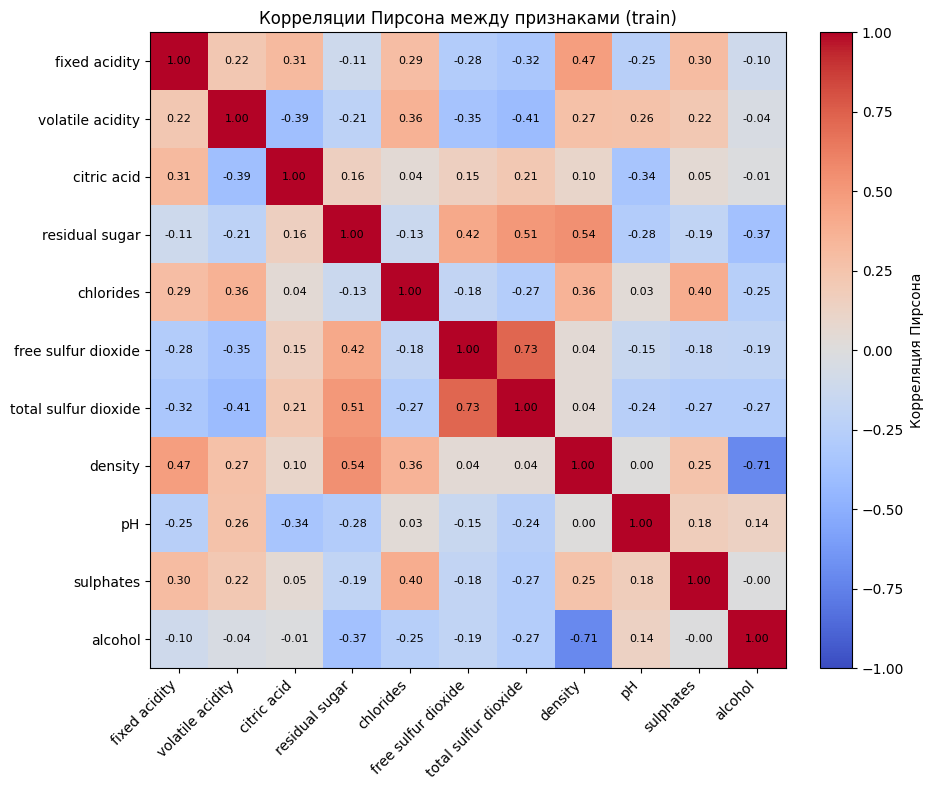

In [328]:
#2.1. Тепловая карта корреляций Пирсона (train)
# Считаем только на train, чтобы не подглядывать в test

corr_matrix = X_train.corr(method="pearson")

plt.figure(figsize=(10, 8))
# imshow — простой визуал без лишних зависимостей
im = plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Корреляция Пирсона")

# Подписи осей — имена признаков
ticks = np.arange(len(corr_matrix.columns))
plt.xticks(ticks, corr_matrix.columns, rotation=45, ha="right")
plt.yticks(ticks, corr_matrix.columns)

# Числа на ячейках
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

plt.title("Корреляции Пирсона между признаками (train)")
plt.tight_layout()
plt.show()


**Как читать тепловую карту**

- Каждая ячейка — корреляция Пирсона двух признаков на **train** (от −1 до +1).
- **Красный**: прямая связь (оба растут вместе); **синий**: обратная; **около 0**: почти нет линейной связи.
- На **диагонали** всегда 1.00 — признак сам с собой; на неё не смотрим.
- Ищем яркие ячейки **вне диагонали** с **|r| > 0.7** — такие пары «дублируют» друг друга.
- Типичные сильные пары в винах: free/total sulfur dioxide (прямая), density/alcohol (обратная).

**Вывод:** карта нужна, чтобы найти избыточные признаки (мультиколлинеарность). Из каждой сильной пары дальше оставляем один признак — с большей |корреляцией с target|. Считаем на train, чтобы не подглядывать в test.

In [329]:
#2.2. Пары с |корреляция| > 0.7

strong_pairs = []
cols = list(corr_matrix.columns)

# Верхний треугольник матрицы (без диагонали)
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            strong_pairs.append({
                "feature_a": cols[i],
                "feature_b": cols[j],
                "corr": round(float(corr_value), 3)
            })

pairs_df = pd.DataFrame(strong_pairs)
print("Пары с |корреляция| > 0.7:")
if len(pairs_df) == 0:
    print("  Таких пар нет")
else:
    display(pairs_df)


Пары с |корреляция| > 0.7:


,feature_a,feature_b,corr
0,free sulfur dioxide,total sulfur dioxide,0.725
1,density,alcohol,-0.706


Почему признаки с |корреляцией| > 0.7 могут ухудшать модель:

1. Мультиколлинеарность — два признака несут почти одну информацию.
   Веса линейной модели становятся неустойчивыми.

2. Переобучение — лишняя размерность без новой пользы.

3. Хуже интерпретируемость — вклад «размазывается» между похожими колонками.

Вывод: из каждой сильной пары оставляем один признак
(тот, у кого |корреляция с target| выше).

In [330]:
# --- 2.4. Удаляем один признак из каждой сильной пары ---

train_with_target = X_train.copy()

# Добавляем колонку target (y) — нужна, чтобы посчитать corr(признак, target)
train_with_target["target"] = y_train.values

# Считаем корреляции Пирсона для всех колонок, берём только столбец "target"
# .drop("target") — убираем корреляцию target с самим собой (она = 1)
target_corr = train_with_target.corr(method="pearson")["target"].drop("target")

# Печатаем заголовок таблицы
print("Корреляция признаков с target (|r| по убыванию):")

display(
    target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
    .round(4)
    .to_frame("corr_with_target")
)

features_to_drop = [] # Имена для удаления

drop_log = [] # Логи

# Перебираем все сильные пары из шага 2.2
for row in strong_pairs:
    # Имена двух признаков в текущей паре
    feat_a = row["feature_a"]
    feat_b = row["feature_b"]

    # Если один из них уже в списке на удаление — пару пропускаем (чтобы не удалить оба признака подряд)
    if feat_a in features_to_drop or feat_b in features_to_drop:
        continue

    # |корреляция с target| для двух признаков
    corr_a = abs(target_corr[feat_a])
    corr_b = abs(target_corr[feat_b])

    if corr_a >= corr_b:
        keep_feat, drop_feat = feat_a, feat_b
    else:
        keep_feat, drop_feat = feat_b, feat_a

    features_to_drop.append(drop_feat)

    drop_log.append({
        "pair": feat_a + " <-> " + feat_b,  # исходная пара
        "keep": keep_feat,                  # кого оставили
        "keep_|corr_target|": round(abs(target_corr[keep_feat]), 3),  # |r| у оставленного
        "drop": drop_feat,                  # кого удалили
        "drop_|corr_target|": round(abs(target_corr[drop_feat]), 3),  # |r| у удалённого
    })

print()
print("Решения по парам:")
# Таблица: по каждой паре — keep / drop
display(pd.DataFrame(drop_log))

# Применяем удаления к train и test
X_train_clean = X_train.drop(columns=features_to_drop)
X_test_clean = X_test.drop(columns=features_to_drop)

print()
print("Было признаков:", X_train.shape[1])
print("Стало признаков:", X_train_clean.shape[1])
print("Удалили:", features_to_drop)
print("Остались:", list(X_train_clean.columns))


Корреляция признаков с target (|r| по убыванию):


,corr_with_target
alcohol,0.3845
density,-0.2781
chlorides,-0.1640
volatile acidity,-0.1516
residual sugar,-0.0624
citric acid,0.0498
total sulfur dioxide,-0.0481
fixed acidity,-0.0477
sulphates,0.0207
pH,0.0198



Решения по парам:


,pair,keep,keep_|corr_target|,drop,drop_|corr_target|
0,free sulfur dioxide <-> total sulfur dioxide,total sulfur dioxide,0.048,free sulfur dioxide,0.007
1,density <-> alcohol,alcohol,0.385,density,0.278



Было признаков: 11
Стало признаков: 9
Удалили: ['free sulfur dioxide', 'density']
Остались: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol']


In [ ]:
#2.5. Baseline: все признаки после очистки корреляций
# Точка отсчёта: с ней сравниваем SelectKBest, RFE и PCA

baseline_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=3000,
        solver="liblinear", # для маленьких датасетов
        random_state=RANDOM_STATE
    ))
])

baseline_test = fit_and_eval(
    baseline_pipe, X_train_clean, y_train, X_test_clean, y_test
)

print("Baseline на test (все", X_train_clean.shape[1], "признака после очистки корреляций):")
display(pd.DataFrame([{
    "method": "baseline",
    "n_features": X_train_clean.shape[1],
    **baseline_test
}]).round(4))


Baseline на test (все 9 признака после очистки корреляций):


,method,n_features,roc_auc,fit_sec
0,baseline,9,0.8174,0.0128


### Часть 3. Filter-методы отбора

**SelectKBest** смотрит на каждый признак отдельно (f_classif)
и оставляет топ-k самых связанных с target.

In [332]:
#3.1. SelectKBest: отбор топ-5 признаков

K_BEST = 5

selector_kbest = SelectKBest(score_func=f_classif, k=K_BEST)
selector_kbest.fit(X_train_clean, y_train)

# Имена отобранных признаков
mask_kbest = selector_kbest.get_support()
features_kbest = list(X_train_clean.columns[mask_kbest])

# Таблица F-scores
scores_df = pd.DataFrame({
    "feature": X_train_clean.columns,
    "f_score": selector_kbest.scores_,
    "selected": mask_kbest
}).sort_values("f_score", ascending=False).reset_index(drop=True)

print("SelectKBest: топ-5 признаков:")
print(features_kbest)
print()
display(scores_df.round(2))


SelectKBest: топ-5 признаков:
['volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'alcohol']



,feature,f_score,selected
0,alcohol,784.65,True
1,chlorides,124.96,True
2,volatile acidity,106.41,True
3,residual sugar,17.69,True
4,citric acid,11.24,True
5,total sulfur dioxide,10.47,False
6,fixed acidity,10.30,False
7,sulphates,1.94,False
8,pH,1.78,False


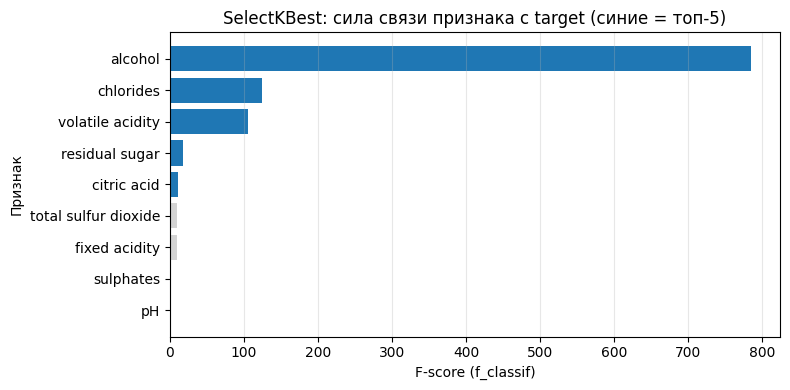

In [333]:
#3.2. График: сила связи признака с target (F-score)
# Визуал в стиле урока: простой plot + grid

# Сортируем по score для горизонтального bar
plot_df = scores_df.sort_values("f_score", ascending=True)

plt.figure(figsize=(8, 4))
colors = ["C0" if sel else "lightgray" for sel in plot_df["selected"]]
plt.barh(plot_df["feature"], plot_df["f_score"], color=colors)
plt.xlabel("F-score (f_classif)")
plt.ylabel("Признак")
plt.title("SelectKBest: сила связи признака с target (синие = топ-5)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


In [334]:
#3.3. Обучаем логистическую регрессию на топ-5 + ROC-AUC

selectk_pipe = Pipeline([
    ("select", SelectKBest(score_func=f_classif, k=K_BEST)),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=3000,
        solver="liblinear",
        random_state=RANDOM_STATE # random — чтобы модель училась одинаково от запуск
    ))
])

selectk_test = fit_and_eval(
    selectk_pipe, X_train_clean, y_train, X_test_clean, y_test
)

# Падение ROC-AUC относительно baseline
selectk_drop = drop_pct(selectk_test["roc_auc"], baseline_test["roc_auc"])

print("Отобранные признаки (SelectKBest):")
print(features_kbest)
print()
print("ROC-AUC (test):", round(selectk_test["roc_auc"], 4))
print("Время обучения (сек):", round(selectk_test["fit_sec"], 4))
print("Падение ROC-AUC vs baseline, %:", round(selectk_drop, 4))
print("(отрицательное число = качество выросло)")
print()

display(pd.DataFrame([
    {
        "method": "baseline (все признаки)",
        "n_features": X_train_clean.shape[1],
        **baseline_test
    },
    {
        "method": "SelectKBest k=5",
        "n_features": K_BEST,
        **selectk_test,
    },
]).round(4))


Отобранные признаки (SelectKBest):
['volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'alcohol']

ROC-AUC (test): 0.8034
Время обучения (сек): 0.0098
Падение ROC-AUC vs baseline, %: 1.7092
(отрицательное число = качество выросло)



,method,n_features,roc_auc,fit_sec
0,baseline (все признаки),9,0.8174,0.0128
1,SelectKBest k=5,5,0.8034,0.0098


### Часть 4. Wrapper метод (RFE)

**RFE** учит модель и по кругу выкидывает самые слабые признаки.
По условию задания: оставить **5** признаков,
оценивающая модель — логистическая регрессия.

In [335]:
# --- 4.1. RFE: отбор 5 признаков ---
# RFE = Recursive Feature Elimination:
# учим модель: выкидываем самый слабый признак: повторяем, пока не останется нужное число признаков.

# Сколько признаков оставить
N_RFE = 5

rfe_pipe = Pipeline([
    # Шаг 1: масштабируем признаки (mean=0, std=1)
    # Нужно, потому что дальше линейная модель смотрит на веса
    ("scaler", StandardScaler()),

    # Шаг 2: RFE — отбирает ровно N_RFE признаков
    ("rfe", RFE(
        # estimator — «внутренняя» модель, по чьим весам судят о важности
        estimator=LogisticRegression(
            max_iter=3000,              # макс. число итераций обучения
            solver="liblinear",         # солвер для логистической регрессии
            random_state=RANDOM_STATE   # фиксируем случайность: воспроизводимость
        ),
        n_features_to_select=N_RFE      # оставить ровно 5 признаков
    )),

    # Шаг 3: финальная модель — учится уже только на отобранных признаках
    ("clf", LogisticRegression(
        max_iter=3000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])

# Обучаем весь pipeline на train
# (scaler: RFE отбирает признаки: clf учится на них)
rfe_pipe.fit(X_train_clean, y_train)

# Достаём шаг "rfe" из pipeline
# support_ — булева маска: True = признак отобран, False = выкинут
mask_rfe = rfe_pipe.named_steps["rfe"].support_

# Имена отобранных признаков: берём колонки, где mask_rfe == True
features_rfe = list(X_train_clean.columns[mask_rfe])

# ranking_ — ранг каждого признака:
#   1        = отобран (вошёл в финальные 5)
#   2, 3, …  = чем больше число, тем раньше признак выкинули
ranking_df = pd.DataFrame({
    "feature": X_train_clean.columns,                      # имя признака
    "rank": rfe_pipe.named_steps["rfe"].ranking_,          # ранг RFE
    "selected": mask_rfe                                   # True/False — отобран ли
}).sort_values("rank").reset_index(drop=True)              # сортируем: сначала rank=1

print("RFE: отобранные 5 признаков:")
print(features_rfe)
print()

print("Таблица рангов по всем признакам")
display(ranking_df)


RFE: отобранные 5 признаков:
['volatile acidity', 'residual sugar', 'chlorides', 'sulphates', 'alcohol']

Таблица рангов по всем признакам


,feature,rank,selected
0,volatile acidity,1,True
1,residual sugar,1,True
2,chlorides,1,True
3,sulphates,1,True
4,alcohol,1,True
5,fixed acidity,2,False
6,pH,3,False
7,total sulfur dioxide,4,False
8,citric acid,5,False


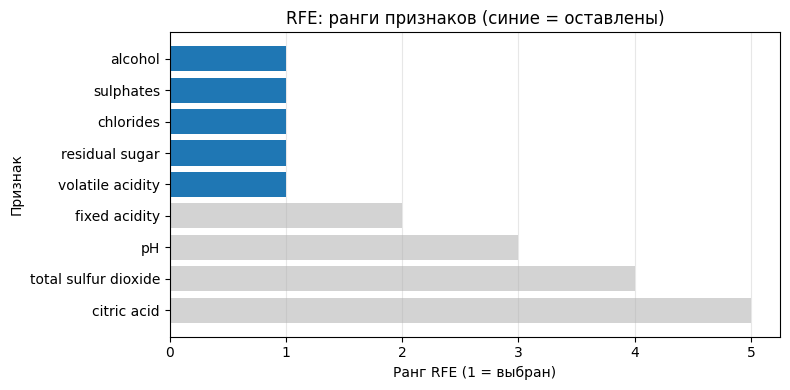

In [336]:
#4.2. График: ранги RFE
# rank=1 — оставили; чем больше rank, тем раньше выкинули

plot_rank = ranking_df.sort_values("rank", ascending=False)

plt.figure(figsize=(8, 4))
colors = ["C0" if sel else "lightgray" for sel in plot_rank["selected"]]
plt.barh(plot_rank["feature"], plot_rank["rank"], color=colors)
plt.xlabel("Ранг RFE (1 = выбран)")
plt.ylabel("Признак")
plt.title("RFE: ранги признаков (синие = оставлены)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


In [337]:
#4.3. ROC-AUC на test для RFE

rfe_test = fit_and_eval(
    rfe_pipe, X_train_clean, y_train, X_test_clean, y_test
)
rfe_drop = drop_pct(rfe_test["roc_auc"], baseline_test["roc_auc"])

print("Отобранные признаки (RFE):")
print(features_rfe)
print()
print("ROC-AUC (test):", round(rfe_test["roc_auc"], 4))
print("Время обучения (сек):", round(rfe_test["fit_sec"], 4))
print("Падение ROC-AUC vs baseline, %:", round(rfe_drop, 4))
print()

display(pd.DataFrame([
    {
        "method": "baseline (все признаки)",
        "n_features": X_train_clean.shape[1],
        **baseline_test
    },
    {
        "method": "RFE n=5",
        "n_features": N_RFE,
        **rfe_test
    },
]).round(4))


Отобранные признаки (RFE):
['volatile acidity', 'residual sugar', 'chlorides', 'sulphates', 'alcohol']

ROC-AUC (test): 0.8137
Время обучения (сек): 0.0274
Падение ROC-AUC vs baseline, %: 0.4514



,method,n_features,roc_auc,fit_sec
0,baseline (все признаки),9,0.8174,0.0128
1,RFE n=5,5,0.8137,0.0274


In [338]:
#4.4. Сравниваем наборы SelectKBest и RFE

sel = set(features_kbest)
rfe = set(features_rfe)

print("SelectKBest:", sorted(features_kbest))
print("RFE:        ", sorted(features_rfe))
print()
print("Общие (выбрали оба):", sorted(sel & rfe))
print("Только SelectKBest:", sorted(sel - rfe))
print("Только RFE:        ", sorted(rfe - sel))
print()

# Сводная таблица filter vs wrapper
comparison_fs = pd.DataFrame([
    {
        "method": "baseline",
        "n_features": X_train_clean.shape[1],
        **baseline_test
    },
    {
        "method": "SelectKBest k=5",
        "n_features": K_BEST,
        **selectk_test
    },
    {
        "method": "RFE n=5",
        "n_features": N_RFE,
        **rfe_test
    },
])
comparison_fs["auc_drop_pct_vs_baseline"] = drop_pct(
    comparison_fs["roc_auc"], baseline_test["roc_auc"]
)
display(comparison_fs.round(4))


SelectKBest: ['alcohol', 'chlorides', 'citric acid', 'residual sugar', 'volatile acidity']
RFE:         ['alcohol', 'chlorides', 'residual sugar', 'sulphates', 'volatile acidity']

Общие (выбрали оба): ['alcohol', 'chlorides', 'residual sugar', 'volatile acidity']
Только SelectKBest: ['citric acid']
Только RFE:         ['sulphates']



,method,n_features,roc_auc,fit_sec,auc_drop_pct_vs_baseline
0,baseline,9,0.8174,0.0128,0.0000
1,SelectKBest k=5,5,0.8034,0.0098,1.7092
2,RFE n=5,5,0.8137,0.0274,0.4514


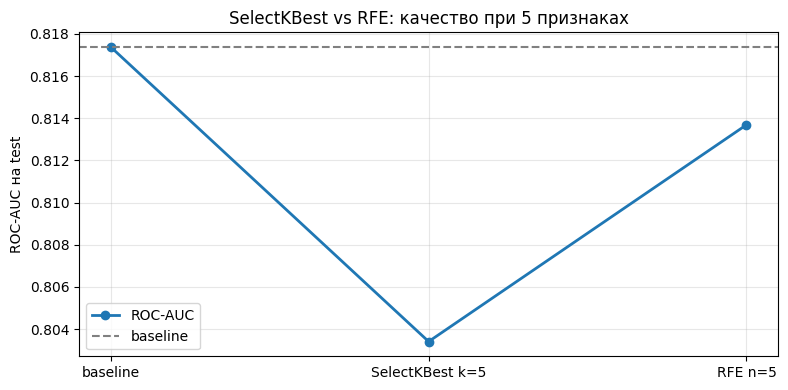

Лучший ROC-AUC (SelectKBest vs RFE): RFE n=5 = 0.8137


In [339]:
# --- 4.5. График: качество vs метод (SelectKBest / RFE) ---

plt.figure(figsize=(8, 4))
methods = comparison_fs["method"].tolist()
aucs = comparison_fs["roc_auc"].tolist()
plt.plot(methods, aucs, marker="o", linewidth=2, label="ROC-AUC")
plt.axhline(
    baseline_test["roc_auc"],
    linestyle="--",
    color="gray",
    label="baseline"
)
plt.ylabel("ROC-AUC на test")
plt.title("SelectKBest vs RFE: качество при 5 признаках")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Одна строка: у кого лучше ROC-AUC — SelectKBest или RFE
fs_only = comparison_fs[comparison_fs["method"].str.contains("SelectKBest|RFE")]
best_row = fs_only.loc[fs_only["roc_auc"].idxmax()]
print("Лучший ROC-AUC (SelectKBest vs RFE):", best_row["method"], "=", round(best_row["roc_auc"], 4))


Почему наборы признаков могут отличаться:

1. SelectKBest (filter)
   - Смотрит на каждый признак ОТДЕЛЬНО (f_classif).
   - Не учитывает, как признаки работают ВМЕСТЕ.
   - Быстрый и простой.

2. RFE (wrapper)
   - Смотрит на признаки В СОСТАВЕ модели.
   - Убирает слабые по вкладу (весам) по кругу.
   - Учитывает взаимодействие признаков, но медленнее.

Различия нормальны:
filter = «кто сильнее связан с y поодиночке»,
wrapper = «какой набор лучше для этой модели».

### Часть 5. Преобразование признаков (PCA)

PCA **не выкидывает** старые колонки, а делает **новые оси**
(главные компоненты).  
Перед PCA обязательно **StandardScaler**.  
По условию: ищем минимум компонент для **≥ 90%** дисперсии.

In [340]:
# --- 5.1. StandardScaler перед PCA (обязательно!) ---
# PCA ищет направления максимальной дисперсии.
# Без масштаба «победят» признаки с большими числами.

# 1) Создаём стандартизатор (mean=0, std=1 для каждого признака)
scaler_pca = StandardScaler()

# 2) На train: запоминаем mean/std и сразу масштабируем
X_train_scaled = scaler_pca.fit_transform(X_train_clean)

# 3) На test: только применяем те же mean/std (без fit — без подглядывания)
X_test_scaled = scaler_pca.transform(X_test_clean)

print("Данные масштабированы.")
print("Форма train:", X_train_scaled.shape)
print("mean ~ 0:", np.round(X_train_scaled.mean(axis=0), 3)[:5], "...")
print("std  ~ 1:", np.round(X_train_scaled.std(axis=0), 3)[:5], "...")


Данные масштабированы.
Форма train: (4524, 9)
mean ~ 0: [-0. -0.  0. -0.  0.] ...
std  ~ 1: [1. 1. 1. 1. 1.] ...


In [341]:
# --- 5.2. Накопленная объяснённая дисперсия (компоненты 1..10) ---
# plot + линия цели + вертикаль «хватит n»

# Сколько признаков (колонок) сейчас в масштабированном train
n_features_clean = X_train_scaled.shape[1]

# По заданию смотрим компоненты от 1 до 10,
# но не больше, чем есть признаков (PCA не может сделать больше осей, чем колонок)
n_comp_max = min(10, n_features_clean)

# Создаём PCA: разложить данные на n_comp_max главных компонент
pca_full = PCA(n_components=n_comp_max, random_state=RANDOM_STATE)

# Учимся только на train: находим направления максимальной дисперсии
pca_full.fit(X_train_scaled)

# Доля дисперсии каждой компоненты (PC1, PC2, ...), сумма всех = 1.0
# Например: [0.28, 0.20, ...]: PC1 объясняет 28% разброса
shares = pca_full.explained_variance_ratio_

# Накопленная сумма долей: сколько % разброса закрыли первыми 1, 2, 3, ... осями
# Например: [0.28, 0.48, 0.64, ...]: двумя осями уже 48%
cum_var = np.cumsum(shares)

print("Доля каждой компоненты:", np.round(shares, 4))
print("Накопили по порядку:   ", np.round(cum_var, 4))


Доля каждой компоненты: [0.2864 0.2038 0.1504 0.0987 0.0663 0.0605 0.0558 0.0467 0.0314]
Накопили по порядку:    [0.2864 0.4902 0.6406 0.7393 0.8056 0.8661 0.922  0.9686 1.    ]


Минимальное число компонент (осей) для >= 90% дисперсии: 7
Фактически объяснено: 0.922


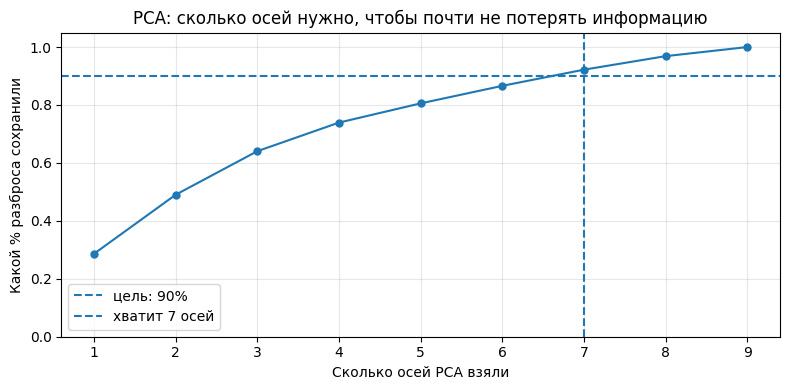

In [342]:
#5.3. Минимум компонент для >= 90% дисперсии

TARGET_VAR = 0.90

# searchsorted: первый индекс, где cum_var >= 0.90
if cum_var[-1] < TARGET_VAR:
    n_components_90 = len(cum_var)
else:
    n_components_90 = int(np.searchsorted(cum_var, TARGET_VAR) + 1)

print("Минимальное число компонент (осей) для >= 90% дисперсии:", n_components_90)
print("Фактически объяснено:", round(float(cum_var[n_components_90 - 1]), 4))

plt.figure(figsize=(8, 4))
plt.plot(
    np.arange(1, len(cum_var) + 1),
    cum_var,
    marker="o",
    markersize=5
)
plt.axhline(TARGET_VAR, linestyle="--", label="цель: 90%")
plt.axvline(
    n_components_90,
    linestyle="--",
    label="хватит " + str(n_components_90) + " осей"
)
plt.xlabel("Сколько осей PCA взяли")
plt.ylabel("Какой % разброса сохранили")
plt.title("PCA: сколько осей нужно, чтобы почти не потерять информацию")
plt.xticks(range(1, len(cum_var) + 1))
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# --- 5.4. Логистическая регрессия на PCA-компонентах + ROC-AUC ---

# Собираем pipeline из 3 шагов (идут строго по порядку)
pca_pipe = Pipeline([
    # 1) Масштабируем признаки (обязательно перед PCA)
    ("scaler", StandardScaler()),

    # 2) PCA: старые признаки: n_components_90 новых осей
    #    (столько, сколько нужно для >= 90% дисперсии)
    ("pca", PCA(n_components=n_components_90, random_state=RANDOM_STATE)),

    # 3) Логистическая регрессия учится уже на новых осях (PC1, PC2, ...)
    ("clf", LogisticRegression(
        max_iter=3000,                 # максимум итераций обучения
        solver="liblinear",            # способ решения задачи оптимизации
        random_state=RANDOM_STATE      # чтобы результат повторялся
    )),
])

# Учим pipeline на train, считаем ROC-AUC и время на test
# fit_and_eval сам делает: fit: predict_proba: roc_auc_score
pca_test = fit_and_eval(
    pca_pipe, X_train_clean, y_train, X_test_clean, y_test
)

# На сколько % ROC-AUC PCA хуже/лучше baseline
# плюс = хуже, минус = лучше
pca_drop = drop_pct(pca_test["roc_auc"], baseline_test["roc_auc"])

# Маленькая таблица: baseline vs PCA рядом
summary_pca = pd.DataFrame([
    {
        # Строка 1: модель на всех старых признаках
        "method": "baseline (все колонки)",
        "dim": X_train_clean.shape[1],   # сколько колонок было
        **baseline_test                  # roc_auc и fit_sec из baseline
    },
    {
        # Строка 2: модель на новых осях PCA
        "method": "PCA (" + str(n_components_90) + " осей)",
        "dim": n_components_90,          # сколько новых осей взяли
        **pca_test                       # roc_auc и fit_sec у PCA
    },
])

# Добавляем столбец: падение ROC-AUC относительно baseline (в %)
summary_pca["auc_drop_pct_vs_baseline"] = drop_pct(
    summary_pca["roc_auc"], baseline_test["roc_auc"]
)

print("Число компонент:", n_components_90)
print("ROC-AUC (test):", round(pca_test["roc_auc"], 4))
print("Время обучения (сек):", round(pca_test["fit_sec"], 4))
print("Падение ROC-AUC vs baseline, %:", round(pca_drop, 4))
print("(отрицательное = PCA даже лучше baseline)")
display(summary_pca.round(4))


Число компонент: 7
ROC-AUC (test): 0.8077
Время обучения (сек): 0.0129
Падение ROC-AUC vs baseline, %: 1.189
(отрицательное = PCA даже лучше baseline)


,method,dim,roc_auc,fit_sec,auc_drop_pct_vs_baseline
0,baseline (все колонки),9,0.8174,0.0128,0.000
1,PCA (7 осей),7,0.8077,0.0129,1.189


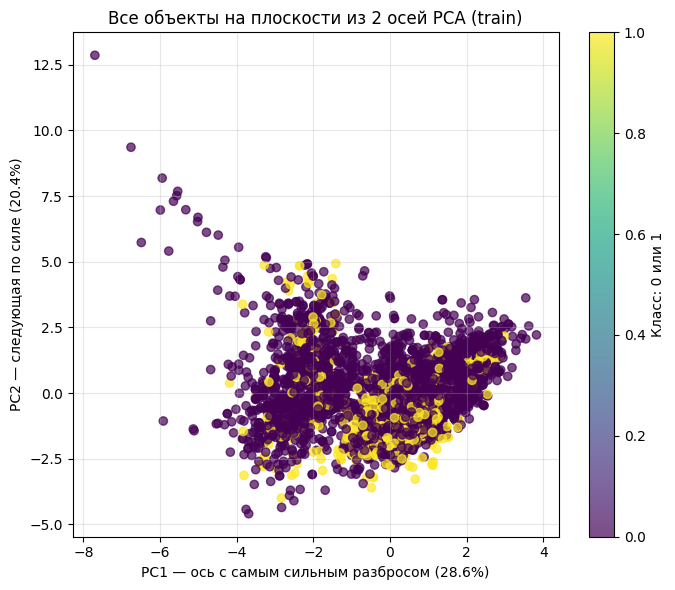

Доля дисперсии PC1 + PC2: 0.4902


In [344]:
#5.5. Визуализация: первые 2 главные компоненты
# scatter + colorbar по классу

pca_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=RANDOM_STATE)),
])

# Каждая строка: 2 числа: (PC1, PC2)
X_train_2d = pca_2d.fit_transform(X_train_clean)
var_2d = pca_2d.named_steps["pca"].explained_variance_ratio_

plt.figure(figsize=(7, 6))
sc = plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train,
    alpha=0.7
)
plt.xlabel(
    "PC1 — ось с самым сильным разбросом ("
    + str(round(var_2d[0] * 100, 1))
    + "%)"
)
plt.ylabel(
    "PC2 — следующая по силе ("
    + str(round(var_2d[1] * 100, 1))
    + "%)"
)
plt.title("Все объекты на плоскости из 2 осей PCA (train)")
plt.colorbar(sc, label="Класс: 0 или 1")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Доля дисперсии PC1 + PC2:", round(var_2d.sum(), 4))


Как читать график:
- Если цвета частично разъехались — PCA сохраняет структуру классов.
- Если цвета перемешаны — в 2D разделить сложно;
  для модели мы берём больше осей (те, что дают >= 90%).

### Общее сравнение методов

Три критерия:
1. **Качество** — ROC-AUC на test  
2. **Сокращение размерности** — сколько признаков/компонент осталось  
3. **Скорость обучения** — fit_sec  
Плюс интерпретируемость: имена признаков vs «смеси» PCA.

In [345]:
#6. Итоговая таблица (стиль упрощённого урока)

result_checks = pd.DataFrame([
    {
        "method": "Baseline",
        "dim_before": X_train_clean.shape[1],
        "dim_after": X_train_clean.shape[1],
        "roc_auc": baseline_test["roc_auc"],
        "fit_sec": baseline_test["fit_sec"],
        "auc_drop_pct_test": 0.0,
        "ok_under_2pct": True,
        "interpretable": "Да"
    },
    {
        "method": "SelectKBest",
        "dim_before": X_train_clean.shape[1],
        "dim_after": K_BEST,
        "roc_auc": selectk_test["roc_auc"],
        "fit_sec": selectk_test["fit_sec"],
        "auc_drop_pct_test": selectk_drop,
        "ok_under_2pct": selectk_drop < 2,
        "interpretable": "Да"
    },
    {
        "method": "RFE",
        "dim_before": X_train_clean.shape[1],
        "dim_after": N_RFE,
        "roc_auc": rfe_test["roc_auc"],
        "fit_sec": rfe_test["fit_sec"],
        "auc_drop_pct_test": rfe_drop,
        "ok_under_2pct": rfe_drop < 2,
        "interpretable": "Да"
    },
    {
        "method": "PCA",
        "dim_before": X_train_clean.shape[1],
        "dim_after": n_components_90,
        "roc_auc": pca_test["roc_auc"],
        "fit_sec": pca_test["fit_sec"],
        "auc_drop_pct_test": pca_drop,
        "ok_under_2pct": pca_drop < 2,
        "interpretable": "Нет"
    },
])

display(result_checks.round(4))

print()
print("=== Как читать таблицу ===")
print("dim_before / dim_after — сколько колонок (или компонент) было и стало.")
print("roc_auc — качество на test.")
print("fit_sec — время обучения pipeline.")
print("auc_drop_pct_test — % изменения ROC-AUC vs baseline (минус = лучше).")
print("ok_under_2pct — уложились ли в правило «просадка < 2%».")
print("interpretable — можно ли объяснить результат через химические признаки.")


,method,dim_before,dim_after,roc_auc,fit_sec,auc_drop_pct_test,ok_under_2pct,interpretable
0,Baseline,9,9,0.8174,0.0128,0.0000,True,Да
1,SelectKBest,9,5,0.8034,0.0098,1.7092,True,Да
2,RFE,9,5,0.8137,0.0274,0.4514,True,Да
3,PCA,9,7,0.8077,0.0129,1.1890,True,Нет



=== Как читать таблицу ===
dim_before / dim_after — сколько колонок (или компонент) было и стало.
roc_auc — качество на test.
fit_sec — время обучения pipeline.
auc_drop_pct_test — % изменения ROC-AUC vs baseline (минус = лучше).
ok_under_2pct — уложились ли в правило «просадка < 2%».
interpretable — можно ли объяснить результат через химические признаки.


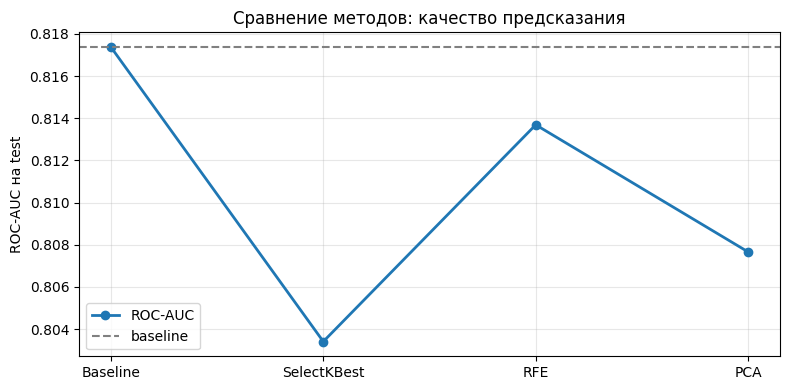

In [346]:
#6.1. График: ROC-AUC всех методов vs baseline

plt.figure(figsize=(8, 4))
plt.plot(
    result_checks["method"],
    result_checks["roc_auc"],
    marker="o",
    linewidth=2,
    label="ROC-AUC"
)
plt.axhline(
    baseline_test["roc_auc"],
    linestyle="--",
    color="gray",
    label="baseline"
)
plt.ylabel("ROC-AUC на test")
plt.title("Сравнение методов: качество предсказания")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


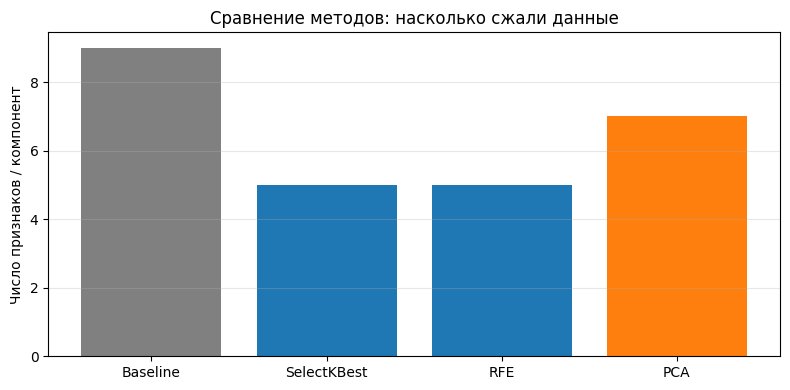

In [347]:
#6.2. График: размерность после сжатия

plt.figure(figsize=(8, 4))
plt.bar(
    result_checks["method"],
    result_checks["dim_after"],
    color=["gray", "C0", "C0", "C1"]
)
plt.ylabel("Число признаков / компонент")
plt.title("Сравнение методов: насколько сжали данные")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


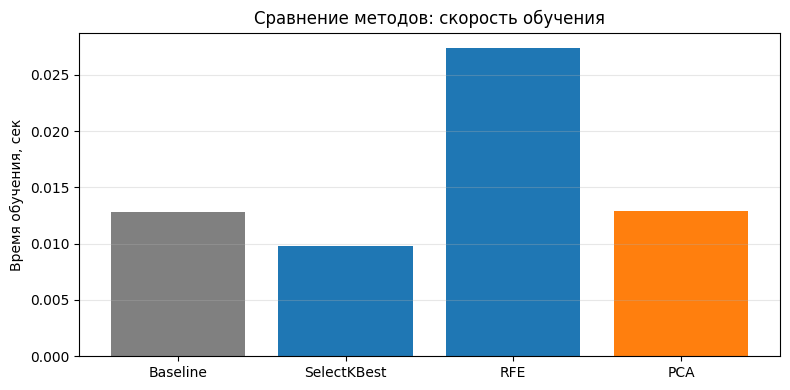

In [348]:
#6.3. График: скорость обучения

plt.figure(figsize=(8, 4))
plt.bar(
    result_checks["method"],
    result_checks["fit_sec"],
    color=["gray", "C0", "C0", "C1"]
)
plt.ylabel("Время обучения, сек")
plt.title("Сравнение методов: скорость обучения")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 📝 Выводы

Какой подход показал лучший баланс между качеством, скоростью и интерпретируемостью?

ОБЩИЙ ВЫВОД

Критерии сравнения:
1) качество (ROC-AUC на test);
2) сокращение числа признаков;
3) скорость обучения + интерпретируемость.

SelectKBest (filter)
  + Быстрый отбор, простая логика.
  + Оставляет исходные химические признаки.
  + ROC-AUC обычно близок к baseline при k=5.
  - Не учитывает взаимодействие признаков.

RFE (wrapper)
  + Учитывает вклад признаков внутри модели.
  + Тоже оставляет понятные имена признаков.
  + Часто ROC-AUC чуть выше или не хуже SelectKBest.
  - Сам отбор медленнее (повторные обучения).

PCA
  + Сжимает пространство, убирает корреляции «внутри».
  + Полезно при очень большой размерности.
  - Компоненты — смеси, плохо объясняются химику/технологу.

------------------------------------------------------------
Рекомендация для качества продуктов по химии:
------------------------------------------------------------

1) Сначала убрать сильные корреляции (|r| > 0.7).
2) Затем SelectKBest или RFE (топ-5 признаков).

Почему:
  * ROC-AUC близко к baseline (часто просадка < 2%);
  * размерность падает заметно;
  * можно объяснить, какие показатели важны.

PCA — когда важнее сжатие, а не интерпретация.

Итог: RFE (или SelectKBest для скорости pipeline)
+ логистическая регрессия на 5 признаках —
лучший баланс качества, скорости и интерпретируемости.